# Idea

This notebook's goal is feature engineering using:
- seaborn feature correlation heatmap,
- XGBoost feature importance method (*),
- SHAP analysis.

*This requires calling a diagnostic XGBoost model. The model will account for class imbalance \[95/5\]. The experiment will be saved using mlflow "simbox_fraud_detection" which will track the whole project.

---

### Imports

In [1]:
from pathlib import Path

import mlflow
import mlflow.xgboost

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import shap

import xgboost as xgb

from sklearn.metrics import (
    average_precision_score,
    roc_auc_score
)

### Paths and MLflow

In [2]:
PROJECT_ROOT = Path.cwd().parent.parent

DATA_PATH = PROJECT_ROOT / "data"

TRAIN_PATH = DATA_PATH / "dvc" / "train_v5.parquet"

mlflow.set_tracking_uri(
    f"file:{PROJECT_ROOT / 'mlruns'}"
)

mlflow.set_experiment(
    "simbox_fraud_detection"
)

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)


<Experiment: artifact_location='file:c:\\Users\\ali.farhat\\Documents\\simbox-project\\mlruns/181740959998191728', creation_time=1781294983928, experiment_id='181740959998191728', last_update_time=1781294983928, lifecycle_stage='active', name='simbox_fraud_detection', tags={}, trace_location=None, workspace='default'>

### Load datasets

In [3]:
train_df = pd.read_parquet(TRAIN_PATH)

print(train_df.shape)

train_df.head()

# Features and Target

X = train_df.drop(
    columns=[
        "label",
        "msisdn",
        "profile_date"
    ],
    errors="ignore"
)

y = train_df["label"]

print(X.shape)

(314610, 26)
(314610, 23)


---
### Correlation Heatmap

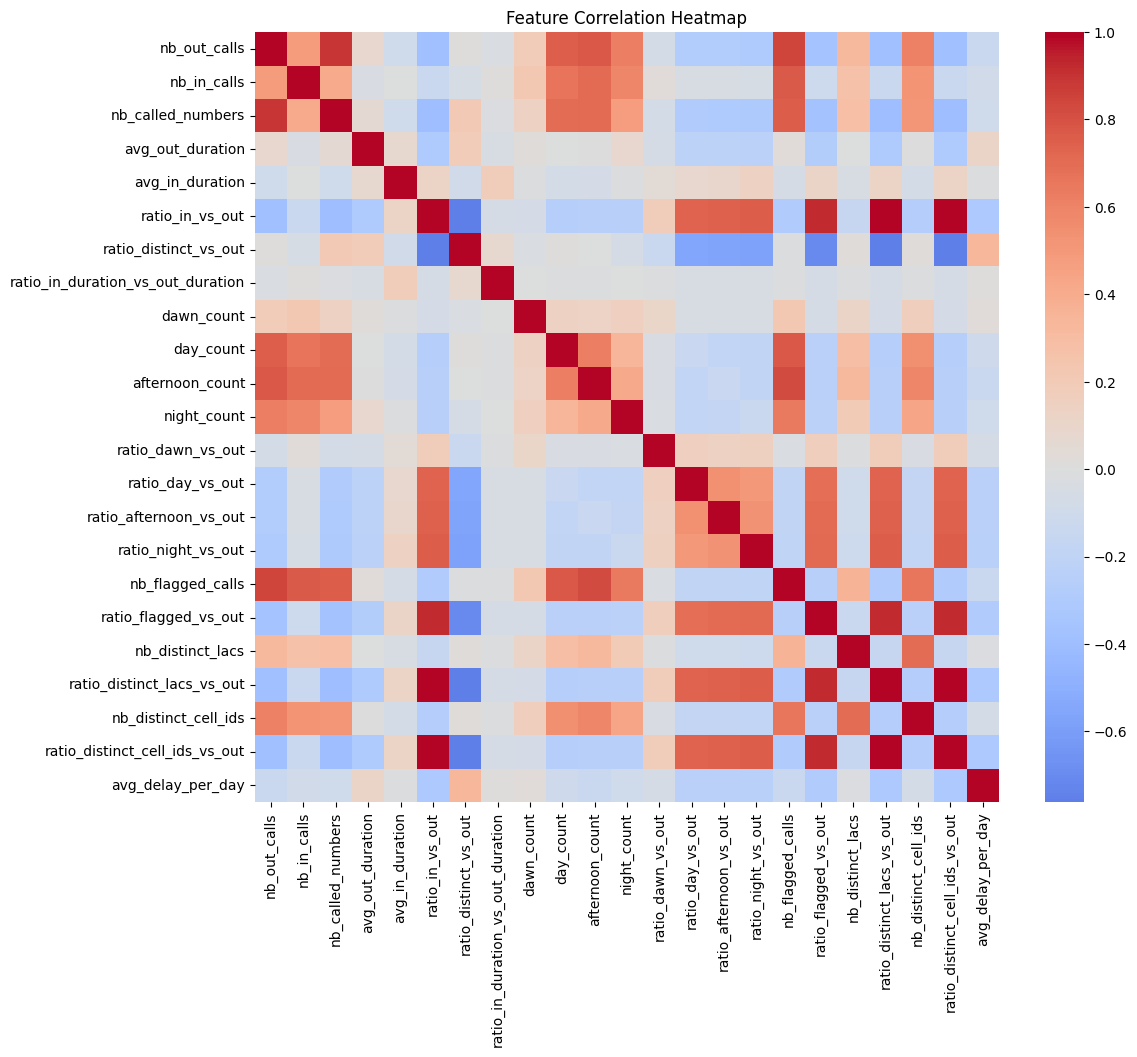

In [4]:
plt.figure(figsize=(12, 10))

corr = X.corr(numeric_only=True)

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Feature Correlation Heatmap"
)

plt.show()

Correlation table

In [5]:
# Compute correlation matrix
corr_matrix = X.corr(numeric_only=True)

# Unstack to feature-pair format
corr_pairs = (
    corr_matrix
    .unstack()
    .reset_index()
)

corr_pairs.columns = ["feature_1", "feature_2", "correlation"]

# Remove self-correlations
corr_pairs = corr_pairs[
    corr_pairs["feature_1"] != corr_pairs["feature_2"]
]

# Take absolute value for ranking strength
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()

# Sort by strongest correlations
corr_pairs = corr_pairs.sort_values(
    "abs_correlation",
    ascending=False
)

# Remove duplicate pairs (A-B vs B-A)
corr_pairs["sorted_pair"] = corr_pairs.apply(
    lambda row: tuple(sorted([row["feature_1"], row["feature_2"]])),
    axis=1
)

corr_pairs = corr_pairs.drop_duplicates("sorted_pair")

# Final output
corr_pairs = corr_pairs.drop(columns=["sorted_pair"])

display(corr_pairs.head(30))

,feature_1,feature_2,correlation,abs_correlation
458,ratio_distinct_lacs_vs_out,ratio_distinct_cell_ids_vs_out,1.000000,1.000000
136,ratio_in_vs_out,ratio_distinct_cell_ids_vs_out,1.000000,1.000000
442,ratio_distinct_lacs_vs_out,ratio_in_vs_out,1.000000,1.000000
132,ratio_in_vs_out,ratio_flagged_vs_out,0.921642,0.921642
500,ratio_distinct_cell_ids_vs_out,ratio_flagged_vs_out,0.921642,0.921642
454,ratio_distinct_lacs_vs_out,ratio_flagged_vs_out,0.921642,0.921642
46,nb_called_numbers,nb_out_calls,0.894289,0.894289
368,nb_flagged_calls,nb_out_calls,0.843124,0.843124
246,afternoon_count,nb_flagged_calls,0.823570,0.823570
10,nb_out_calls,afternoon_count,0.778378,0.778378


---
### XGBoost feature importance

Set up baseline XGBoost and MLflow

In [6]:
# Setting parameters
scale_pos_weight = (
    (y == 0).sum()
    /
    (y == 1).sum()
)

params = {
    "objective": "binary:logistic",
    "eval_metric": "aucpr",
    "max_depth": 6,
    "scale_pos_weight": scale_pos_weight,
    "seed": 42,
    "n_jobs": -1,
    "verbosity": 0
}

num_boost_round = 100

print(params)
print("Boosting rounds:", num_boost_round)

# Train xgb model
mlflow.set_experiment(
    "feature_engineering_v5"
)

with mlflow.start_run(
    run_name="xgb_feature_importance"
):

    mlflow.log_params(params)
    mlflow.log_param(
        "num_boost_round",
        num_boost_round
    )

    mlflow.log_input(
        mlflow.data.from_pandas(
            train_df,
            name="train_v5"
        )
    )

    dtrain = xgb.DMatrix(
        X,
        label=y
    )

    model = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=num_boost_round
    )

    mlflow.xgboost.log_model(
        model,
        "model"
    )

print("Training completed")

2026/08/07 20:21:26 INFO mlflow.tracking.fluent: Experiment with name 'feature_engineering_v5' does not exist. Creating a new experiment.


{'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'max_depth': 6, 'scale_pos_weight': np.float64(16.353963263279827), 'seed': 42, 'n_jobs': -1, 'verbosity': 0}
Boosting rounds: 100


2026/08/07 20:21:26 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

c:\Users\ali.farhat\AppData\Local\miniconda3\envs\simbox\Lib\site-packages\mlflow\types\utils.py:440: Us

Training completed


Compute feature importance

In [7]:
importance_dict = model.get_score(
    importance_type="gain"
)

features = X.columns

importance_df = pd.DataFrame({
    "feature": features,
    "importance": [
        importance_dict.get(f, 0)
        for f in features
    ]
})

importance_df = (
    importance_df
    .sort_values(
        "importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(importance_df)

,feature,importance
0,ratio_flagged_vs_out,787.126221
1,ratio_in_vs_out,711.864746
2,nb_in_calls,354.601624
3,nb_called_numbers,227.593796
4,ratio_distinct_vs_out,212.619461
5,avg_out_duration,150.184189
6,nb_flagged_calls,66.595360
7,dawn_count,65.057716
8,ratio_night_vs_out,57.958282
9,nb_distinct_lacs,55.540791


Feature importance plot

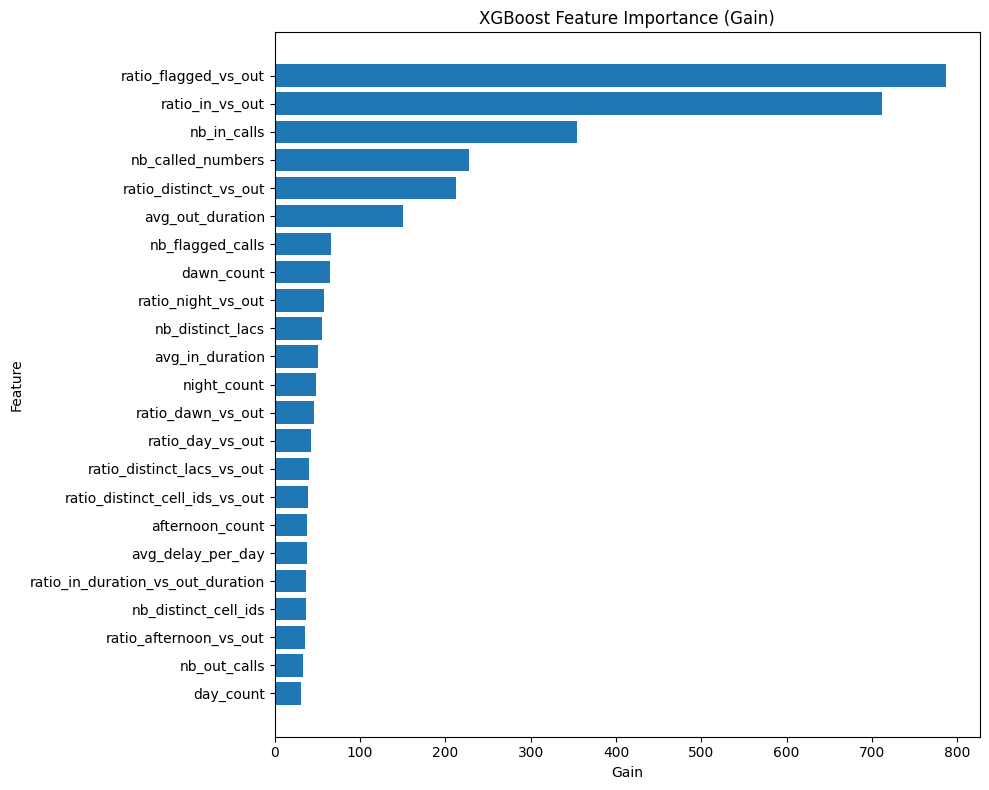

In [8]:
plt.figure(figsize=(10, 8))

plt.barh(
    importance_df["feature"],
    importance_df["importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Gain")
plt.ylabel("Feature")
plt.title(
    "XGBoost Feature Importance (Gain)"
)

plt.tight_layout()
plt.show()

Log feature importance table to MLFlow

In [9]:
with mlflow.start_run(
    run_name="xgb_feature_importance_table"
):

    importance_path = (PROJECT_ROOT / "data" / "results" / "feature_importance_v5.csv")

    importance_df.to_csv(importance_path, index=False)

    mlflow.log_artifact(str(importance_path))

---
### SHAP analysis

In [11]:
sample_size = min(
    5000,
    len(X)
)

X_sample = X.sample(
    sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(
    model
)

shap_values = explainer.shap_values(
    X_sample
)

Summary plot

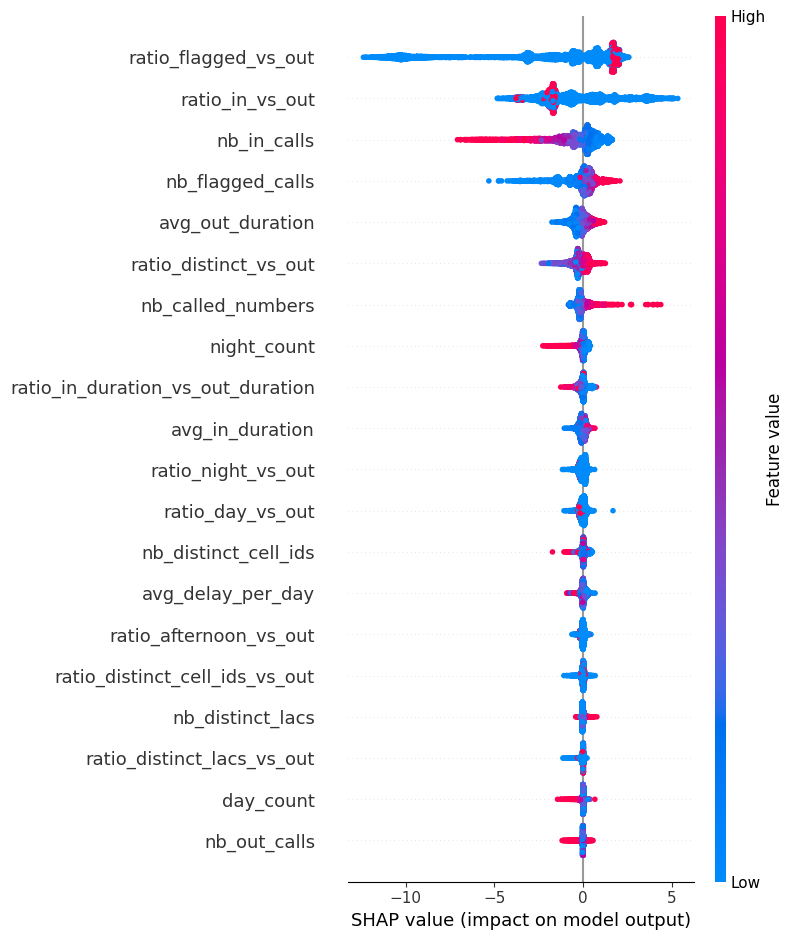

In [12]:
shap.summary_plot(
    shap_values,
    X_sample
)

Bar plot

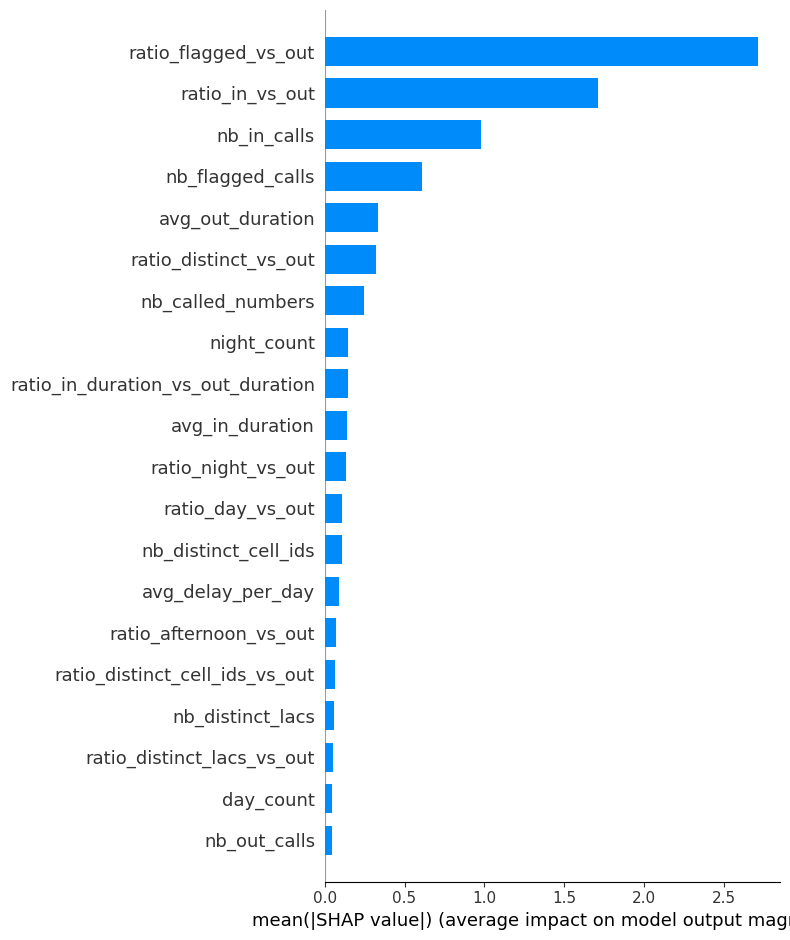

In [13]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

---
### Feature ablation

We ablate sets of features and compare performance to the baseline. We evaluate on a validation set that constitutes days 9-10-11 of the train set.

Define ablation Sets

In [19]:
ablation_sets = {
    "baseline": [],

    "no_flagged_cells": [
        "nb_flagged_calls",
        "ratio_flagged_vs_out"
    ],

    "no_location_features": [
        "nb_flagged_calls",
        "ratio_flagged_vs_out",
        "nb_distinct_lacs",
        "ratio_distinct_lacs_vs_out",
        "nb_distinct_cell_ids",
        "ratio_distinct_cell_ids_vs_out"
    ],

    "no_cell_features": [
        "nb_distinct_cell_ids",
        "ratio_distinct_cell_ids_vs_out"
    ],

    "no_lac_features": [
        "nb_distinct_lacs",
        "ratio_distinct_lacs_vs_out"
    ],

				"no_cell_no_lac_features": [
        "nb_distinct_cell_ids",
								"ratio_distinct_cell_ids_vs_out",
								"nb_distinct_lacs",
							 "ratio_distinct_lacs_vs_out"
				]
}

ablation_sets

{'baseline': [],
 'no_flagged_cells': ['nb_flagged_calls', 'ratio_flagged_vs_out'],
 'no_location_features': ['nb_flagged_calls',
  'ratio_flagged_vs_out',
  'nb_distinct_lacs',
  'ratio_distinct_lacs_vs_out',
  'nb_distinct_cell_ids',
  'ratio_distinct_cell_ids_vs_out'],
 'no_cell_features': ['nb_distinct_cell_ids',
  'ratio_distinct_cell_ids_vs_out'],
 'no_lac_features': ['nb_distinct_lacs', 'ratio_distinct_lacs_vs_out'],
 'no_cell_no_lac_features': ['nb_distinct_cell_ids',
  'ratio_distinct_cell_ids_vs_out',
  'nb_distinct_lacs',
  'ratio_distinct_lacs_vs_out']}

Chronological train/validation split

In [20]:
train_days = sorted(train_df["profile_date"].unique())

train_days_split = train_days[:-3]
val_days = train_days[-3:]

train_part = train_df[
    train_df["profile_date"].isin(train_days_split)
]

val_part = train_df[
    train_df["profile_date"].isin(val_days)
]

print(
    f"Training days: {train_days_split[0]} → {train_days_split[-1]}"
)

print(
    f"Validation days: {val_days[0]} → {val_days[-1]}"
)

Training days: 2022-11-01 00:00:00 → 2022-11-08 00:00:00
Validation days: 2022-11-09 00:00:00 → 2022-11-11 00:00:00


Training/evaluation function

In [21]:
from sklearn.metrics import average_precision_score, roc_auc_score


def train_ablation_model(train_data, val_data, removed_features):

    drop_cols = [
        "msisdn",
        "profile_date",
        "label"
    ] + removed_features

    features = [
        c for c in train_data.columns
        if c not in drop_cols
    ]

    X_train = train_data[features]
    y_train = train_data["label"]

    X_val = val_data[features]
    y_val = val_data["label"]


    scale_pos_weight = (
        (y_train == 0).sum()
        /
        (y_train == 1).sum()
    )


    params = {
        "objective": "binary:logistic",
        "eval_metric": "aucpr",
        "max_depth": 6,
        "scale_pos_weight": scale_pos_weight,
        "seed": 42,
        "n_jobs": -1,
        "verbosity": 0
    }


    model = xgb.train(
        params=params,
        dtrain=xgb.DMatrix(
            X_train,
            label=y_train
        ),
        num_boost_round=100
    )


    val_proba = model.predict(
        xgb.DMatrix(X_val)
    )


    results = {
        "num_features": len(features),
        "pr_auc": average_precision_score(
            y_val,
            val_proba
        ),
        "roc_auc": roc_auc_score(
            y_val,
            val_proba
        )
    }

    return model, results

Run all ablations

In [22]:
ablation_results = []

models = {}

for name, removed_features in ablation_sets.items():

    print(f"Running: {name}")

    model, results = train_ablation_model(
        train_part,
        val_part,
        removed_features
    )

    results["experiment"] = name
    results["removed_features"] = removed_features

    ablation_results.append(results)

    models[name] = model


ablation_results_df = pd.DataFrame(
    ablation_results
)

ablation_results_df = ablation_results_df[
    [
        "experiment",
        "num_features",
        "pr_auc",
        "roc_auc",
        "removed_features"
    ]
]

display(
    ablation_results_df.sort_values(
        "pr_auc",
        ascending=False
    )
)

Running: baseline
Running: no_flagged_cells
Running: no_location_features
Running: no_cell_features
Running: no_lac_features
Running: no_cell_no_lac_features


,experiment,num_features,pr_auc,roc_auc,removed_features
4,no_lac_features,21,0.439152,0.863860,"[nb_distinct_lacs, ratio_distinct_lacs_vs_out]"
3,no_cell_features,21,0.439001,0.864826,"[nb_distinct_cell_ids, ratio_distinct_cell_ids..."
0,baseline,23,0.438835,0.863968,[]
5,no_cell_no_lac_features,19,0.435784,0.863393,"[nb_distinct_cell_ids, ratio_distinct_cell_ids..."
1,no_flagged_cells,21,0.380089,0.798563,"[nb_flagged_calls, ratio_flagged_vs_out]"
2,no_location_features,17,0.376300,0.795993,"[nb_flagged_calls, ratio_flagged_vs_out, nb_di..."


Compare PR-AUC drop from baseline

In [23]:
baseline_score = (
    ablation_results_df
    .loc[
        ablation_results_df.experiment == "baseline",
        "pr_auc"
    ]
    .iloc[0]
)


ablation_results_df["pr_auc_delta_%"] = (
    (
        ablation_results_df["pr_auc"]
        -
        baseline_score
    )
    /
    baseline_score
    *
    100
)


display(
    ablation_results_df.sort_values(
        "pr_auc",
        ascending=False
    )
)

,experiment,num_features,pr_auc,roc_auc,removed_features,pr_auc_delta_%
4,no_lac_features,21,0.439152,0.863860,"[nb_distinct_lacs, ratio_distinct_lacs_vs_out]",0.072366
3,no_cell_features,21,0.439001,0.864826,"[nb_distinct_cell_ids, ratio_distinct_cell_ids...",0.037910
0,baseline,23,0.438835,0.863968,[],0.000000
5,no_cell_no_lac_features,19,0.435784,0.863393,"[nb_distinct_cell_ids, ratio_distinct_cell_ids...",-0.695238
1,no_flagged_cells,21,0.380089,0.798563,"[nb_flagged_calls, ratio_flagged_vs_out]",-13.386738
2,no_location_features,17,0.376300,0.795993,"[nb_flagged_calls, ratio_flagged_vs_out, nb_di...",-14.250074
